# Sistema Inteligente de Gestión de Reuniones (RAG + Agente)
### Trabajo Práctico N°2 — Sistemas Inteligentes con RAG o Agentes
**Materia:** Inteligencia Artificial — Ingeniería en Sistemas de Información

**Integrantes:** Juan Pablo Jaca, Nahuel Berli, Gustavo Giampietro, Alexis Mateo

**Caso de negocio:** un asistente que, a partir del audio de una reunión de trabajo,
transcribe lo hablado, genera un resumen (con gráficos/mapa conceptual), permite
consultar en lenguaje natural lo charlado (RAG) y completa automáticamente una
planilla de reunión según Norma ISO 9001 para que el responsable solo la revise.

> Notebook en construcción — las secciones marcadas con `# TODO` quedan pendientes
> de implementación.


## Índice
1. Instalación y configuración
2. Módulo de Transcripción (Speech-to-Text)
3. Módulo de Resumen y Visualización (texto + mapa conceptual)
4. Módulo RAG (indexación y consultas sobre la reunión)
5. Módulo de Completado de Planilla (ISO 9001)
6. Orquestación — Agente principal (Langchain)
7. Casos de prueba
8. Conclusiones y dificultades (defensa oral)


## 1. Instalación y configuración

In [ ]:
!pip install -q langchain langchain-community langchain-groq \
    langchain-cohere langchain-text-splitters \
    faiss-cpu networkx matplotlib python-dotenv pydantic \
    python-docx whisperx


[notice] A new release of pip is available: 23.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [22]:
import os
from dotenv import load_dotenv
from langchain_groq import ChatGroq
from langchain_cohere import CohereEmbeddings

load_dotenv(override=True)

# --- LLM: Groq ---
if not os.getenv("GROQ_API_KEY"):
    import getpass
    os.environ["GROQ_API_KEY"] = getpass.getpass("GROQ_API_KEY: ")

llm = ChatGroq(
    model="openai/gpt-oss-120b",
    #model="",
    temperature=0
)

# --- Embeddings: Cohere ---
if not os.getenv("COHERE_API_KEY"):
    import getpass
    os.environ["COHERE_API_KEY"] = getpass.getpass("COHERE_API_KEY: ")

# --- HF para WhisperX ---
if not os.getenv("HF_TOKEN"):
    import getpass
    os.environ["HF_TOKEN"] = getpass.getpass("HF_TOKEN: ")

# --- Rutas ---
RUTA_AUDIO = "Simulación de Reunión de Trabajo - UPN.mp3"
RUTA_PLANILLA_SALIDA = "output/planilla_reunion.docx"
RUTA_PLANTILLA_MINUTA = "Minuta de Reunión.docx"
RUTA_TRANSCRIPCION = "output/transcripcion.txt"
RUTA_MAPA_CONCEPTUAL = "output/mapa_conceptual_reunion.png"

In [13]:
print("Ruta del audio:", os.path.abspath(RUTA_AUDIO))
print("¿Existe el audio?:", os.path.exists(RUTA_AUDIO))

print("Ruta de salida:", os.path.abspath(RUTA_TRANSCRIPCION))

Ruta del audio: c:\Users\Pc\Desktop\Estudios_academicos\Sistemas-2026\IA\TPN2\Simulación de Reunión de Trabajo - UPN.mp3
¿Existe el audio?: True
Ruta de salida: c:\Users\Pc\Desktop\Estudios_academicos\Sistemas-2026\IA\TPN2\output\transcripcion.txt


## 2. Módulo de Transcripción (Speech-to-Text)
Convierte el audio de la reunión en texto. Candidato: `whisper` / `faster-whisper`.
Pendiente definir si se agrega diarización (identificar quién habla) — no es
requisito del caso de negocio pero podría enriquecer la planilla (participantes).


In [7]:
import torch
import whisperx

def transcribir_audio(ruta_audio: str, tamanio_modelo: str = "small") -> str:
    """
    Transcribe el audio y separa el texto por hablante.
    """
    device = "cuda" if torch.cuda.is_available() else "cpu"
    compute_type = "float16" if device == "cuda" else "int8"

    # --- Transcripción ---
    modelo = whisperx.load_model(
        tamanio_modelo,
        device,
        compute_type=compute_type
    )

    audio = whisperx.load_audio(ruta_audio)

    resultado = modelo.transcribe(
        audio,
        batch_size=16                       # Modificar para que transcriba mas
    )

    # --- Alineación ---
    modelo_align, metadata = whisperx.load_align_model(
        language_code=resultado["language"],
        device=device
    )

    resultado = whisperx.align(
        resultado["segments"],
        modelo_align,
        metadata,
        audio,
        device
    )

    # --- Diarización ---
    diarizador = whisperx.diarize.DiarizationPipeline(
        token=os.environ["HF_TOKEN"],
        device=device
    )

    segmentos_hablantes = diarizador(audio)

    resultado = whisperx.assign_word_speakers(
        segmentos_hablantes,
        resultado
    )

    # --- Texto por hablante ---
    etiquetas_por_hablante = {}
    lineas = []

    for segmento in resultado["segments"]:
        hablante_raw = segmento.get(
            "speaker",
            "SPEAKER_DESCONOCIDO"
        )

        if hablante_raw not in etiquetas_por_hablante:
            etiquetas_por_hablante[hablante_raw] = (
                f"Persona {len(etiquetas_por_hablante) + 1}"
            )

        lineas.append(
            f"{etiquetas_por_hablante[hablante_raw]}: "
            f"{segmento['text'].strip()}"
        )

    return "\n".join(lineas)

In [8]:
os.makedirs("output", exist_ok=True)

print("Iniciando transcripción...")
transcripcion = transcribir_audio(RUTA_AUDIO)

with open(RUTA_TRANSCRIPCION, "w", encoding="utf-8") as f:
    f.write(transcripcion)

print("Transcripción finalizada.")
print(f"Guardada en: {RUTA_TRANSCRIPCION}")

print("\n--- TRANSCRIPCIÓN ---\n")
print(transcripcion)

Iniciando transcripción...


c:\Users\Pc\Desktop\Estudios_academicos\Sistemas-2026\IA\TPN2\venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\Pc\Desktop\Estudios_academicos\Sistemas-2026\IA\TPN2\venv\lib\site-packages\pyannote\audio\core\io.py:48: UserWarning: 
torchcodec is not installed correctly so built-in audio decoding will fail. Solutions are:
* use audio preloaded in-memory as a {'waveform': (channel, time) torch.Tensor, 'sample_rate': int} dictionary;
* fix torchcodec installation. Error message was:

Could not load libtorchcodec. Likely causes:
          1. FFmpeg is not properly installed in your environment. We support
             versions 4, 5, 6 and 7.
          2. The PyTorch version (2.8.0+cpu) is not compatible with
             this version of TorchCodec. Refer to the version compatibility
             table:
   

2026-09-16 19:48:42 - whisperx.asr - INFO - No language specified, language will be detected for each audio file (increases inference time)
2026-09-16 19:48:42 - whisperx.vads.pyannote - INFO - Performing voice activity detection using Pyannote...


Lightning automatically upgraded your loaded checkpoint from v1.5.4 to v2.6.6. To apply the upgrade to your files permanently, run `python -m lightning.pytorch.utilities.upgrade_checkpoint c:\Users\Pc\Desktop\Estudios_academicos\Sistemas-2026\IA\TPN2\venv\lib\site-packages\whisperx\assets\pytorch_model.bin`


2026-09-16 19:49:18 - whisperx.asr - INFO - Detected language: es (0.89) in first 30s of audio
2026-09-16 19:54:14 - whisperx.diarize - INFO - Loading diarization model: pyannote/speaker-diarization-community-1


c:\Users\Pc\Desktop\Estudios_academicos\Sistemas-2026\IA\TPN2\venv\lib\site-packages\pyannote\audio\models\blocks\pooling.py:103: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\ReduceOps.cpp:1839.)
  std = sequences.std(dim=-1, correction=1)


Transcripción finalizada.
Guardada en: output/transcripcion.txt

--- TRANSCRIPCIÓN ---

Persona 1: Muy buenas noches con todos ustedes, mi nombre es Elen Contreras, soy gerente general de la empresa Pesquera Diamante.
Persona 1: Todos ustedes han sido convocados y convocadas a esta reunión de gerencia muy importante por los cambios que van a venir aquí en Adelante.
Persona 1: Para los que recién están ingresando aquí a la empresa, les voy a explicar brevemente en qué consiste el trabajo que realizamos.
Persona 1: Nosotros somos una especie de empresa dedicada al procesamiento de harina y aceite de pescado, conserva, productos pescos y congelados.
Persona 1: Tenemos nuestra propia flota de embarcaciones y hemos afrontado esta pandemia saliendo airosos.
Persona 1: Pero sabemos que todo ha cambiado y queremos executivos que no teman a enfrentar estos cambios.
Persona 1: Por eso que ustedes han sido convocados y serán presentados el día de hoy.
Persona 1: Estamos ansiosos de escucharlos.
P

## 3. Módulo de Resumen y Visualización
Genera un resumen ejecutivo de la reunión y, si aporta valor, un mapa conceptual
o gráfico de los temas tratados.


In [23]:
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser

TAMANIO_CHUNK = 6000       # caracteres por fragmento
SOLAPAMIENTO_CHUNK = 300

prompt_resumen_stuff = ChatPromptTemplate.from_template(
    "Sos un asistente que resume reuniones de trabajo. A partir de la "
    "siguiente transcripción, escribí un resumen ejecutivo en español, en "
    "viñetas, con los temas tratados y las conclusiones/acuerdos "
    "principales.\n\nTranscripción:\n{texto}"
)

prompt_resumen_parcial = ChatPromptTemplate.from_template(
    "Resumí en español, en pocas viñetas, los temas y conclusiones tratados "
    "en este fragmento de una reunión de trabajo:\n\n{texto}"
)

prompt_resumen_final = ChatPromptTemplate.from_template(
    "Estos son resúmenes parciales de distintos fragmentos de UNA MISMA "
    "reunión de trabajo. Consolidalos en un único resumen ejecutivo en "
    "español, en viñetas, uniendo temas repetidos y sin duplicar "
    "información:\n\n{resumenes_parciales}"
)


def generar_resumen(transcripcion: str) -> str:
    """
    Genera un resumen ejecutivo de la transcripción.

    - Si entra en un solo fragmento: resumen directo (equivalente a "stuff").
    - Si no: resume cada fragmento (map) y combina esos resúmenes en uno
      solo (reduce).
    """
    splitter = RecursiveCharacterTextSplitter(
        chunk_size=TAMANIO_CHUNK, chunk_overlap=SOLAPAMIENTO_CHUNK
    )
    fragmentos = splitter.split_text(transcripcion)
    parser = StrOutputParser()

    if len(fragmentos) == 1:
        chain = prompt_resumen_stuff | llm | parser
        return chain.invoke({"texto": fragmentos[0]})

    # Map: resumen de cada fragmento
    chain_parcial = prompt_resumen_parcial | llm | parser
    resumenes_parciales = [chain_parcial.invoke({"texto": f}) for f in fragmentos]

    # Reduce: combina los resúmenes parciales en uno final
    chain_final = prompt_resumen_final | llm | parser
    return chain_final.invoke({"resumenes_parciales": "\n\n".join(resumenes_parciales)})


In [24]:
import networkx as nx
import matplotlib.pyplot as plt
from pydantic import BaseModel, Field
from typing import List


class NodoConcepto(BaseModel):
    id: str = Field(description="Identificador corto y único del tema (ej. 'tema_1')")
    etiqueta: str = Field(description="Nombre del tema, para mostrar en el gráfico")


class RelacionConcepto(BaseModel):
    origen: str = Field(description="id del nodo origen")
    destino: str = Field(description="id del nodo destino")
    etiqueta: str = Field(description="Relación entre ambos (ej. 'depende de', 'deriva en')")


class MapaConceptual(BaseModel):
    nodos: List[NodoConcepto]
    relaciones: List[RelacionConcepto]


prompt_mapa_conceptual = ChatPromptTemplate.from_template(
    "A partir de este resumen de una reunión de trabajo, extraé entre 4 y "
    "10 temas principales como nodos, y las relaciones entre ellos (ej. "
    "'depende de', 'deriva en', 'se relaciona con').\n\nResumen:\n{resumen}"
)


def graficar_mapa_conceptual(resumen: str) -> MapaConceptual:
    """
    Extrae temas y relaciones del resumen (salida estructurada del LLM,
    with_structured_output) y dibuja el mapa conceptual con networkx.
    Devuelve el objeto MapaConceptual por si se quiere reutilizar (ej. en
    la planilla).
    """
    extractor = llm.with_structured_output(MapaConceptual)
    mapa = extractor.invoke(prompt_mapa_conceptual.format(resumen=resumen))

    grafo = nx.DiGraph()
    etiquetas_nodos = {n.id: n.etiqueta for n in mapa.nodos}
    grafo.add_nodes_from(etiquetas_nodos.keys())
    for r in mapa.relaciones:
        grafo.add_edge(r.origen, r.destino, etiqueta=r.etiqueta)

    posiciones = nx.spring_layout(grafo, seed=42)
    plt.figure(figsize=(9, 6))
    nx.draw(
        grafo, posiciones, with_labels=False, node_color="#a3c9f7",
        node_size=2200, edge_color="#888888", arrows=True,
    )
    nx.draw_networkx_labels(grafo, posiciones, labels=etiquetas_nodos, font_size=9)
    etiquetas_relaciones = nx.get_edge_attributes(grafo, "etiqueta")
    nx.draw_networkx_edge_labels(grafo, posiciones, edge_labels=etiquetas_relaciones, font_size=8)
    plt.title("Mapa conceptual de la reunión")
    plt.axis("off")
    plt.tight_layout()

    RUTA_MAPA_CONCEPTUAL = "output/mapa_conceptual_reunion.png"
    plt.savefig(RUTA_MAPA_CONCEPTUAL, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()

    return mapa


Generando resumen de la reunión...
Resumen generado: output/resumen_reunion.txt
Generando mapa conceptual...


C:\Users\Pc\AppData\Local\Temp\ipykernel_13108\2940835403.py:57: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


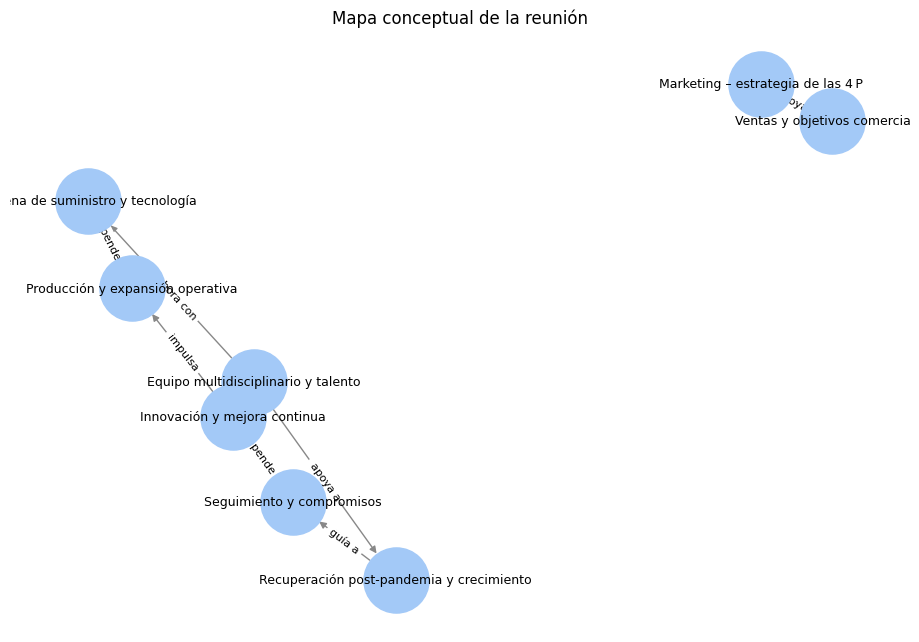

Mapa conceptual generado: output/mapa_conceptual_reunion.png

=== BLOQUE 3 FINALIZADO ===


In [25]:
os.makedirs("output", exist_ok=True)

print("Generando resumen de la reunión...")

# Leer la transcripción generada en el bloque 2
with open(RUTA_TRANSCRIPCION, encoding="utf-8") as f:
    transcripcion = f.read()

# Generar resumen
resumen = generar_resumen(transcripcion)

# Guardar resumen como artefacto
RUTA_RESUMEN = "output/resumen_reunion.txt"

with open(RUTA_RESUMEN, "w", encoding="utf-8") as f:
    f.write(resumen)

print(f"Resumen generado: {RUTA_RESUMEN}")

# Generar mapa conceptual
print("Generando mapa conceptual...")
mapa = graficar_mapa_conceptual(resumen)

print(f"Mapa conceptual generado: {RUTA_MAPA_CONCEPTUAL}")

print("\n=== BLOQUE 3 FINALIZADO ===")

## 4. Módulo RAG — Indexación y Consultas
Permite responder preguntas sobre lo charlado en la reunión (ej. *"¿qué
problemáticas se discutieron y con qué prioridad?"*) recuperando los fragmentos
relevantes de la transcripción.


In [26]:
from langchain_google_genai import GoogleGenerativeAIEmbeddings
from langchain_community.vectorstores import FAISS

TAMANIO_CHUNK_RAG = 1000
SOLAPAMIENTO_CHUNK_RAG = 150

# Embeddings de Cohere para el RAG
embeddings = CohereEmbeddings(
    model="embed-v4.0"
)

prompt_rag = ChatPromptTemplate.from_template(
    "Respondé la pregunta usando SOLO los fragmentos de la reunión que se "
    "muestran abajo como contexto. Si se pide un listado (ej. problemáticas "
    "discutidas y su prioridad), devolvé un listado ordenado por "
    "criticidad. Si el contexto no alcanza para responder, decilo.\n\n"
    "Contexto:\n{contexto}\n\nPregunta: {pregunta}"
)


def crear_vectorstore(transcripcion: str):
    """
    Indexa la transcripción para recuperación semántica (RAG): splitea en
    fragmentos más chicos que los del resumen (para recuperar con
    precisión), genera embeddings y arma un índice FAISS.
    """
    splitter = RecursiveCharacterTextSplitter(
        chunk_size=TAMANIO_CHUNK_RAG, chunk_overlap=SOLAPAMIENTO_CHUNK_RAG
    )
    fragmentos = splitter.split_text(transcripcion)

    #embeddings = embeddings
    return FAISS.from_texts(fragmentos, embeddings)


def consultar_reunion(pregunta: str, vectorstore, k: int = 4) -> str:
    """
    Responde una pregunta en base a lo charlado en la reunión: recupera los
    `k` fragmentos más relevantes del vectorstore y arma la respuesta con
    el LLM en base a ese contexto (RAG).
    """
    retriever = vectorstore.as_retriever(search_kwargs={"k": k})
    fragmentos_relevantes = retriever.invoke(pregunta)                                  # 1. retrieval: busca los k más parecidos
    contexto = "\n\n---\n\n".join(d.page_content for d in fragmentos_relevantes)        # 2. arma el contexto

    chain = prompt_rag | llm | StrOutputParser()
    return chain.invoke({"contexto": contexto, "pregunta": pregunta})                   # 3. generation: el LLM responde SOLO con ese contexto


In [27]:
os.makedirs("output", exist_ok=True)

print("Creando vectorstore para la reunión...")

# Leer la transcripción
with open(RUTA_TRANSCRIPCION, encoding="utf-8") as f:
    transcripcion = f.read()

# Crear índice vectorial FAISS
vectorstore = crear_vectorstore(transcripcion)

print("Vectorstore creado correctamente.")

# Consulta de prueba
PREGUNTA_PRUEBA = "¿Qué problemáticas se discutieron y con qué prioridad?"

print("\nConsultando el RAG...")
respuesta_rag = consultar_reunion(
    PREGUNTA_PRUEBA,
    vectorstore
)

# Mostrar resultado
print("\n=== RESPUESTA DEL RAG ===\n")
print(respuesta_rag)

# Guardar resultado como artefacto
RUTA_RESPUESTA_RAG = "output/respuesta_rag.txt"

with open(RUTA_RESPUESTA_RAG, "w", encoding="utf-8") as f:
    f.write(f"Pregunta: {PREGUNTA_PRUEBA}\n\n")
    f.write(f"Respuesta:\n{respuesta_rag}")

pregunta = "¿Qué personas tienen tareas asignadas?"
print(consultar_reunion(pregunta, vectorstore))

print(f"\nRespuesta RAG guardada en: {RUTA_RESPUESTA_RAG}")
print("\n=== BLOQUE 4 FINALIZADO ===")

Creando vectorstore para la reunión...
Vectorstore creado correctamente.

Consultando el RAG...

=== RESPUESTA DEL RAG ===

**Problemáticas discutidas (ordenadas por criticidad)**  

1. **Impacto de la pandemia en las ventas** – “el tema de la pandemia nos ha afectado un poco, nuestras ventas son disminuidos”  
2. **Necesidad de un nuevo proveedor con altos estándares de calidad y entregas más rápidas** – “Debo trabajar con un nuevo proveedor que también está trabajando con altos estándares de calidad… para que todos sus producciones, sus pedidos sean de manera correcta entregada hace menos tiempo.”  
3. **Adquisición de equipos tecnológicos para mejorar la producción** – “estamos a puertas de poder adquirir los equipos, esos equipos tecnológicos para poder mejorar nuestra producción.”  
4. **Mejoras en el almacenamiento de materias primas** – “Y también el tema del almacenamiento, el almacenamiento de las materias primas que son indispensables para la producción que tenemos en esta em

## 5. Módulo de Completado de Planilla (Norma ISO 9001)
A partir de la transcripción y el resumen, completa automáticamente la planilla
estandarizada de reunión (para que el responsable solo la revise y ajuste).


In [28]:
from pydantic import BaseModel, Field
from typing import List

# Roster fijo de puestos de la tabla ASISTENTES de la planilla (en orden)
ROLES_ASISTENTES = [
    "Presidente",
    "Gerente Administrativo Financiero",
    "Subgerente Calidad",
    "Subgerente Mantenimiento",
    "Subgerente Operaciones",
    "Subgerente Logística",
    "Responsable de Recursos Humanos",
    "Director Comercial",
    "Director",
]


class Asistente(BaseModel):
    puesto: str = Field(description=f"Uno de {ROLES_ASISTENTES}, o el puesto del invitado si no está en esa lista")
    nombre: str = Field(description="Nombre y apellido de quien ocupa ese puesto; string vacío si no asistió")
    asistio: bool = Field(description="True si participó de la reunión según la transcripción")
    motivo_ausencia: str = Field(description="Motivo de la ausencia si se menciona en la transcripción; vacío si no aplica o no se sabe")


class Acuerdo(BaseModel):
    responsable: str = Field(description="Responsable de la tarea/acuerdo")
    actividad: str = Field(description="Actividad/tarea/acción acordada")
    plazo: str = Field(description="Plazo o fecha de ejecución acordada")


class PlanillaReunionISO9001(BaseModel):
    """Minuta de Reunión — planilla estandarizada de la fábrica (ISO 9001)."""
    fecha: str = Field(description="Fecha de la reunión, formato dd/mm/aaaa")
    hora_inicio: str = Field(description="Hora de inicio, formato HH:MM")
    hora_fin: str = Field(description="Hora de fin, formato HH:MM")
    lugar: str = Field(description="Lugar de la reunión")
    objetivo: str = Field(description="Objetivo/motivo de la reunión, en 1-2 oraciones")
    asistentes: List[Asistente] = Field(description=f"Un ítem por cada puesto de {ROLES_ASISTENTES}, más invitados externos que hayan participado")
    orden_del_dia: List[str] = Field(description="Temas tratados, en el orden en que se charlaron (máx. 12)")
    acuerdos: List[Acuerdo] = Field(description="Acuerdos/tareas con responsable y plazo (máx. 6)")

In [29]:
prompt_planilla = ChatPromptTemplate.from_template(
    "Sos un asistente que completa la Minuta de Reunión de una fábrica "
    "(formato ISO 9001) a partir de la transcripción y el resumen de una "
    "reunión de trabajo.\n\n"
    "Los puestos esperados son: " + ", ".join(ROLES_ASISTENTES) + ". Para "
    "cada uno de esos puestos, indicá si participó y quién (nombre y "
    "apellido) según la transcripción; si no hay evidencia de que haya "
    "participado, marcalo como no asistió. Si aparecen invitados externos "
    "no listados, agregalos también.\n\n"
    "Resumen:\n{resumen}\n\nTranscripción completa:\n{transcripcion}"
)


def completar_planilla(transcripcion: str, resumen: str) -> PlanillaReunionISO9001:
    """
    Completa la planilla de reunión (Minuta ISO 9001) con salida
    estructurada del LLM sobre PlanillaReunionISO9001.
    """
    chain = prompt_planilla | llm.with_structured_output(PlanillaReunionISO9001)
    return chain.invoke({"resumen": resumen, "transcripcion": transcripcion})


from docx import Document

def exportar_planilla(planilla: PlanillaReunionISO9001, ruta_plantilla: str, ruta_salida: str):
    """
    Completa la plantilla Word "Minuta de Reunión" (la que usa la fábrica)
    con los datos de `planilla` y guarda el resultado en `ruta_salida`,
    para que el responsable de la reunión solo la revise y firme.
    """
    doc = Document(ruta_plantilla)
    tabla_encabezado, tabla_asistentes, tabla_orden_dia, tabla_acuerdos = doc.tables[:4]

    # --- Encabezado: fecha, horario, lugar, objetivo -----------------------
    tabla_encabezado.rows[0].cells[1].text = planilla.fecha
    tabla_encabezado.rows[0].cells[3].text = planilla.hora_inicio
    tabla_encabezado.rows[1].cells[1].text = planilla.lugar
    tabla_encabezado.rows[1].cells[3].text = planilla.hora_fin
    tabla_encabezado.rows[3].cells[0].text = planilla.objetivo

    # --- Asistentes: matchea por puesto contra el roster fijo de la fila ---
    asistentes_por_puesto = {a.puesto: a for a in planilla.asistentes}
    for fila in tabla_asistentes.rows[2:11]:
        puesto = fila.cells[1].text.strip()
        asistente = asistentes_por_puesto.pop(puesto, None)
        if asistente and asistente.asistio:
            fila.cells[0].text = asistente.nombre
        elif asistente and asistente.motivo_ausencia:
            fila.cells[0].text = f"Ausente ({asistente.motivo_ausencia})"

    # invitados / puestos fuera del roster fijo -> filas libres (11, 12, 13)
    filas_libres = tabla_asistentes.rows[11:14]
    for fila, asistente in zip(filas_libres, asistentes_por_puesto.values()):
        fila.cells[0].text = asistente.nombre
        fila.cells[1].text = asistente.puesto

    # --- Orden del día (hasta 12 temas) -------------------------------------
    for fila, tema in zip(tabla_orden_dia.rows[1:13], planilla.orden_del_dia):
        fila.cells[1].text = tema

    # --- Acuerdos (hasta 6) ---------------------------------------------
    for fila, acuerdo in zip(tabla_acuerdos.rows[2:8], planilla.acuerdos):
        fila.cells[0].text = acuerdo.responsable
        fila.cells[1].text = acuerdo.actividad
        fila.cells[2].text = acuerdo.plazo

    doc.save(ruta_salida)
    # Nota: al pisar el .text de una celda vacía se pierde el formato de
    # esa celda puntual (fuente/tamaño); si hace falta conservarlo, TODO:
    # escribir sobre el/los runs existentes en vez de reasignar .text

In [30]:
os.makedirs("output", exist_ok=True)

print("Preparando datos para completar la planilla...")

# Leer transcripción
with open(RUTA_TRANSCRIPCION, encoding="utf-8") as f:
    transcripcion = f.read()

# Si el resumen todavía no está disponible, generarlo
if "resumen" not in globals():
    print("No se encontró el resumen. Generándolo...")
    resumen = generar_resumen(transcripcion)

print("Generando información estructurada de la reunión...")

# Obtener los datos estructurados mediante el LLM
planilla = completar_planilla(
    transcripcion,
    resumen
)

print("Datos de la planilla generados correctamente.")

# Mostrar los datos obtenidos
print("\n=== DATOS DE LA PLANILLA ===\n")
print(planilla.model_dump_json(indent=2, ensure_ascii=False))

# Exportar a la plantilla Word
exportar_planilla(
    planilla,
    RUTA_PLANTILLA_MINUTA,
    RUTA_PLANILLA_SALIDA
)

print(f"\nPlanilla completada: {RUTA_PLANILLA_SALIDA}")
print("\n=== BLOQUE 5 FINALIZADO ===")

Preparando datos para completar la planilla...
Generando información estructurada de la reunión...
Datos de la planilla generados correctamente.

=== DATOS DE LA PLANILLA ===

{
  "fecha": "17/09/2026",
  "hora_inicio": "18:00",
  "hora_fin": "20:00",
  "lugar": "Sala de Juntas, Pesquera Diamante",
  "objetivo": "Presentar propuestas innovadoras de cada área para impulsar el crecimiento post‑pandemia.",
  "asistentes": [
    {
      "puesto": "Presidente",
      "nombre": "",
      "asistio": false,
      "motivo_ausencia": ""
    },
    {
      "puesto": "Gerente Administrativo Financiero",
      "nombre": "",
      "asistio": false,
      "motivo_ausencia": ""
    },
    {
      "puesto": "Subgerente Calidad",
      "nombre": "",
      "asistio": false,
      "motivo_ausencia": ""
    },
    {
      "puesto": "Subgerente Mantenimiento",
      "nombre": "",
      "asistio": false,
      "motivo_ausencia": ""
    },
    {
      "puesto": "Subgerente Operaciones",
      "nombre": "",
  

## 6. Orquestación — Agente principal (Langchain)
Combina los módulos anteriores como *tools* de un agente, o como un pipeline
secuencial simple (a definir cuál conviene según lo visto en clase).


In [31]:
from langchain.agents import create_agent
from langchain.tools import tool

# Estado de "la reunión actual", que arma procesar_reunion() y consumen
# las tools del agente (el LLM no puede pasarles la transcripción/índice
# completos como argumento de tool call).
transcripcion_actual = None
resumen_actual = None
vectorstore_actual = None


def procesar_reunion(transcripcion: str):
    """
    Pipeline determinístico que corre una vez por reunión: genera el
    resumen, el mapa conceptual y el índice para RAG (módulos 3 y 4), y
    deja todo en variables globales para que las tools del agente lo usen.
    """
    global transcripcion_actual, resumen_actual, vectorstore_actual
    transcripcion_actual = transcripcion
    resumen_actual = generar_resumen(transcripcion)
    graficar_mapa_conceptual(resumen_actual)
    vectorstore_actual = crear_vectorstore(transcripcion)


@tool
def ConsultarReunion(pregunta: str) -> str:
    """Responde preguntas sobre lo charlado en la reunión (temas, prioridades, acuerdos), en base a lo indexado con RAG."""
    if vectorstore_actual is None:
        return "Todavía no se procesó ninguna reunión (correr procesar_reunion primero)."
    return consultar_reunion(pregunta, vectorstore_actual)


@tool
def CompletarPlanilla() -> str:
    """Completa la Minuta de Reunión (ISO 9001) de la reunión ya procesada y la guarda en RUTA_PLANILLA_SALIDA."""
    if resumen_actual is None or transcripcion_actual is None:
        return "Todavía no se procesó ninguna reunión (correr procesar_reunion primero)."
    planilla = completar_planilla(transcripcion_actual, resumen_actual)
    exportar_planilla(planilla, RUTA_PLANTILLA_MINUTA, RUTA_PLANILLA_SALIDA)
    return f"Planilla completada y guardada en {RUTA_PLANILLA_SALIDA}"


agente = create_agent(
    model=llm,
    tools=[ConsultarReunion, CompletarPlanilla],
    system_prompt=(
        "Sos el asistente de reuniones de la fábrica. Usá ConsultarReunion "
        "para responder preguntas sobre lo charlado en la reunión, y "
        "CompletarPlanilla cuando te pidan generar/completar la minuta."
    ),
)

# Ejemplo de uso:
# procesar_reunion(transcripcion)
# respuesta = agente.invoke({"messages": [
#     {"role": "user", "content": "¿qué problemáticas se discutieron y con qué prioridad?"}
# ]})
# print(respuesta["messages"][-1].content)

## 7. Casos de prueba

**Resumen ejecutivo de la reunión (unificado y sin duplicaciones)**  

- **Contexto y apertura**  
  - Elen Contreras (Gerente General) abre la sesión señalando que la reunión responde a los cambios del mercado post‑pandemia y a la necesidad de impulsar la innovación y la competitividad.  
  - Breve descripción de la empresa: procesamiento de harina y aceite de pescado, producción de conservas y productos congelados, con flota propia y centro de administración (CAME).

- **Objetivos estratégicos**  
  - Adaptarse rápidamente a la nueva demanda del mercado.  
  - Mejorar la eficiencia operativa y comercial mediante inversión en tecnología, equipos y talento.  
  - Consolidar una oferta premium con precios competitivos y mayor presencia en puntos de venta.

- **Producción y operaciones**  
  - Formar un equipo multidisciplinario (operarios, analistas, visitadores) coordinado con RR.HH. y almacén para optimizar el flujo de materias primas y productos terminados.  
  - Adquirir nueva maqui

C:\Users\Pc\AppData\Local\Temp\ipykernel_13108\2940835403.py:57: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


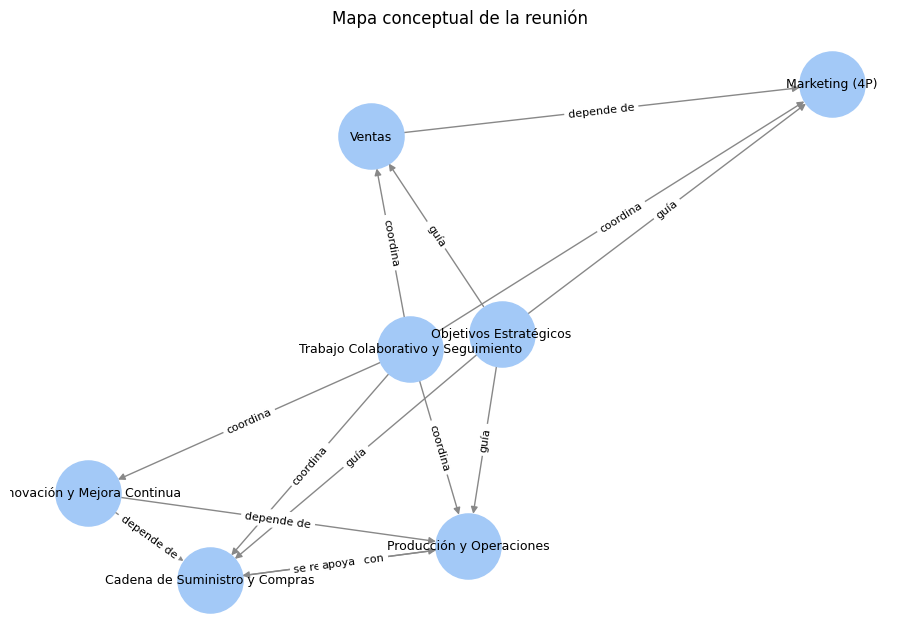

**Problemáticas discutidas (ordenadas por criticidad según la información de la reunión)**  

1. **Disminución de ventas por la pandemia**  
   - *Fragmento:* “sabemos que el tema de la pandemia nos ha afectado un poco, nuestras ventas son disminuidos” (Persona 4).  

2. **Necesidad de reforzar la producción para cumplir pedidos a tiempo**  
   - *Fragmento:* “trabajar con un nuevo proveedor … altos estándares de calidad … ayudar muchísimo a la empresa para que todos sus producciones, sus pedidos sean de manera correcta entregada hace menos tiempo” (Persona 4).  
   - *Fragmento:* “estamos a puertas de poder adquirir los equipos, esos equipos tecnológicos para poder mejorar nuestra producción” (Persona 5).  

3. **Problemas de almacenamiento de materias primas**  
   - *Fragmento:* “el tema del almacenamiento, el almacenamiento de las materias primas que son indispensables para la producción que tenemos en esta empresa” (Persona 5).  

4. **Desafío de fijar un precio competitivo y rent

C:\Users\Pc\AppData\Local\Temp\ipykernel_13108\2940835403.py:57: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


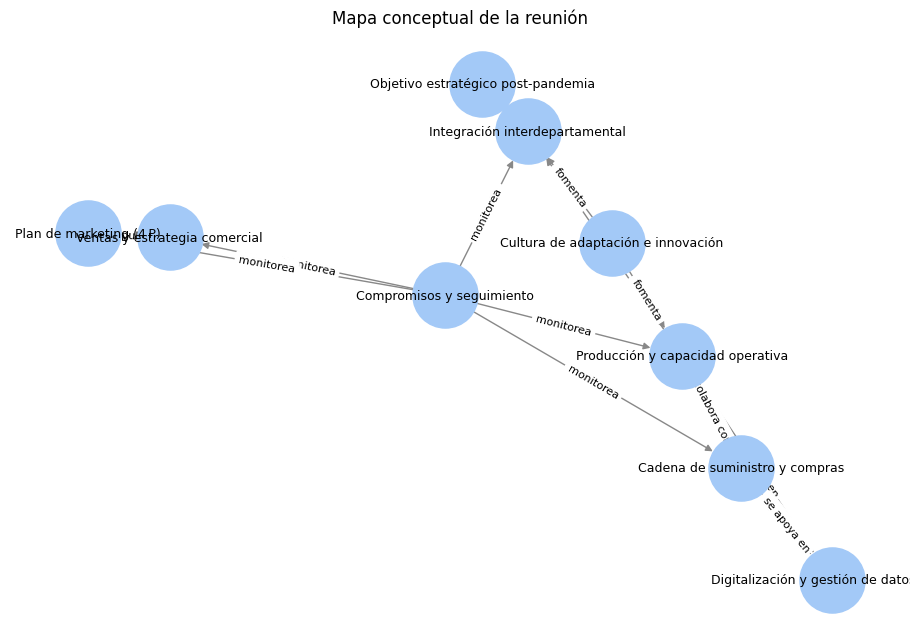

**Problemáticas discutidas y su prioridad (según la valoración de la reunión):**

| # | Problemática | Prioridad asignada* | Comentario / Evidencia |
|---|--------------|---------------------|------------------------|
| 1 | **Disminución de ventas por la pandemia** | **Alta** | “nuestras ventas son disminuidos…” (Persona 4). Es el factor que afecta directamente la sostenibilidad del negocio. |
| 2 | **Necesidad de un nuevo proveedor que garantice entregas correctas y a menor tiempo** | **Alta** | “para el inicio del 2023 está considerando una… propuesta… con un nuevo proveedor” (Persona 4). La cadena de suministro es crítica para reactivar la producción. |
| 3 | **Adquisición de equipos tecnológicos para mejorar la producción** | **Media‑Alta** | “estamos a puertas de poder adquirir los equipos, esos equipos tecnológicos para poder mejorar nuestra producción.” (Persona 5). Permite aumentar la capacidad y la eficiencia, pero depende de la disponibilidad de fondos y del proveedor. |
| 4 

In [32]:
with open(RUTA_TRANSCRIPCION, encoding="utf-8") as f:
    transcripcion = f.read()

# --- Módulo 3: resumen + mapa conceptual --------------------------------
resumen = generar_resumen(transcripcion)
print(resumen)
mapa = graficar_mapa_conceptual(resumen)

# --- Módulo 4: RAG --------------------------------------------------------
vectorstore = crear_vectorstore(transcripcion)
print(consultar_reunion("¿qué problemáticas se discutieron y con qué prioridad?", vectorstore))

# --- Módulo 5: planilla ---------------------------------------------------
planilla = completar_planilla(transcripcion, resumen)
print(planilla.model_dump())
exportar_planilla(planilla, RUTA_PLANTILLA_MINUTA, RUTA_PLANILLA_SALIDA)

# --- Módulo 6: agente (mismo flujo de arriba, pero a través de las tools) -
# NOTA: esto repite las llamadas al LLM que ya se hicieron arriba (gasta más de la cuota de la API). Una vez validado cada 
# módulo por separado, comentar el bloque de arriba y dejar solo este.
procesar_reunion(transcripcion)

respuesta = agente.invoke({"messages": [
    {"role": "user", "content": "¿qué problemáticas se discutieron y con qué prioridad?"}
]})
print(respuesta["messages"][-1].content)

respuesta_planilla = agente.invoke({"messages": [
    {"role": "user", "content": "Completá la planilla de esta reunión"}
]})
print(respuesta_planilla["messages"][-1].content)


## 8. Conclusiones y dificultades
*(Para completar de cara a la defensa oral: decisiones de diseño tomadas,
dificultades encontradas y cómo se resolvieron, resultados obtenidos.)*

- Caso de negocio: _pendiente_
- Decisiones de diseño: _pendiente_
- Dificultades: _pendiente_
- Resultados: _pendiente_
